# Limpeza de dados

Abaixo temos as bibliotecas que serão utilizadas para a limpeza dos dados.
- pandas: biblioteca utilizada para manipulação e análise de dados, muito utilizado para manipulação de tabelas e séries temporais (dataframes).
- trim_mean: função utilizada para remover espaços em branco no início e no final de strings.

In [12]:
import pandas as pd
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns

- No código abaixo, estamos importando a biblioteca pandas e atribuindo o apelido "pd" para facilitar a utilização da biblioteca em nosso código.
- Inicialmente, utilizamos a função `read_excel()` para ler o arquivo Excel e armazenar os dados em um dataframe chamado 'df'.Utilizamos o sheet_name para especificar a aba do arquivo Excel que queremos ler, e o header = 1, para indicar que a primeira linha do arquivo contém os nomes das colunas (ele pula a primeira linha).
- A lista de colunas que queremos manter é definida na variável 'colunas_para_manter'. 
- Em seguida, a variável 'df_limpo' é criada, contendo apenas as colunas especificadas na lista 'colunas_para_manter', utilizamos o copy() para criar uma cópia do dataframe original, evitando alterações indesejadas no dataframe original.
- A variaével "novos_nomes" é uma lista que contém os novos nomes das colunas que queremos atribuir ao dataframe 'df_limpo'.
- O dataframe 'df_limpo' é atualizado com os novos nomes de colunas utilizando o método `rename()`, que recebe um dicionário mapeando os nomes antigos para os novos nomes.
- Depois, utilizamos o método `dropna()` para remover todas as linhas do dataframe 'df_limpo' que contêm valores ausentes (NaN). Isso é importante para garantir que os dados utilizados na análise estejam completos e não contenham lacunas.
- Por fim, utilizamos o 'print()' com o argumento 'df_limpo.head()' para exibir as primeiras linhas do dataframe 'df_limpo', permitindo verificar se a limpeza e a renomeação das colunas foram realizadas corretamente. A função head() exibe apenas as primeiras linhas do dataframe, facilitando a visualização dos dados.

In [ ]:
df_estacao = pd.read_excel('TELHADO_VERDE_atualizado 1.xlsx', sheet_name = 'TELHADO_VERDE_27042026_01052026', header=1)

colunas_para_manter = [
    'Data Hora, GMT-04:00', 
    'Velocidade do Vento, m/s (LGR S/N: 10995967, SEN S/N: 9991, LBL: Vvel)',
    'Radiação Solar, W/m² (LGR S/N: 10995967, SEN S/N: 20556793, LBL: Rad (Wm2))',
    'Temp_Convencional_ºC',
    'Temp_Esmeralda_ºC',
    'Temp_Amendoim_ºC',
    'Temp_AR_ºC',
    'HR, % (LGR S/N: 10995967, SEN S/N: 20858871, LBL: UR (%))',
    'Chuva, mm (LGR S/N: 10995967, SEN S/N: 20895944, LBL: Prec (mm))',
    'Teor de Água, m³/m³ (LGR S/N: 10995967, SEN S/N: 20896168, LBL: Usoil Esmeralda)',
    'Teor de Água, m³/m³ (LGR S/N: 10995967, SEN S/N: 20896180, LBL: Usoil Amendoim)'
]

df_limpo = df_estacao[colunas_para_manter].copy()

novos_nomes = {
    'Data Hora, GMT-04:00': 'data_hora', 
    'Velocidade do Vento, m/s (LGR S/N: 10995967, SEN S/N: 9991, LBL: Vvel)': 'vento_ms',
    'Radiação Solar, W/m² (LGR S/N: 10995967, SEN S/N: 20556793, LBL: Rad (Wm2))' : 'radiacao_wm2',
    'Temp_Convencional_ºC': 'temp_convencional',
    'Temp_Esmeralda_ºC': 'temp_esmeralda',
    'Temp_Amendoim_ºC': 'temp_amendoim',
    'Temp_AR_ºC': 'temp_ar',
    'HR, % (LGR S/N: 10995967, SEN S/N: 20858871, LBL: UR (%))': 'umidade_ar',
    'Chuva, mm (LGR S/N: 10995967, SEN S/N: 20895944, LBL: Prec (mm))': 'chuva_mm',
    'Teor de Água, m³/m³ (LGR S/N: 10995967, SEN S/N: 20896168, LBL: Usoil Esmeralda)': 'umidade_solo_esmeralda',
    'Teor de Água, m³/m³ (LGR S/N: 10995967, SEN S/N: 20896180, LBL: Usoil Amendoim)': 'umidade_solo_amendoim'

}

df_limpo = df_limpo.rename(columns=novos_nomes)


df_limpo = df_limpo.dropna() 
#df_limpo['data_hora'] = pd.to_datetime(df_limpo['data_hora'], format='%m/%d/%y %Hh%Mmin%Ss')
#df_limpo['data_hora'] = pd.date_range(start='2026-04-27 12:00:00', periods=len(df_limpo), freq='min')
#df_limpo = df_limpo.set_index('data_hora')

print(df_limpo.head())

             data_hora  vento_ms  radiacao_wm2  temp_convencional  \
0  04/27/26 12h0min57s      0.33        1049.4             34.704   
1  04/27/26 12h1min57s      0.33        1095.6             34.730   
2  04/27/26 12h2min57s      0.33        1086.9             34.757   
3  04/27/26 12h3min57s      0.33        1075.6             35.022   
4  04/27/26 12h4min57s      0.33         940.6             35.182   

   temp_esmeralda  temp_amendoim  temp_ar  umidade_ar  chuva_mm  \
0          38.393         35.985   36.335     56400.0       0.0   
1          38.476         36.012   36.444     54300.0       0.0   
2          38.532         36.012   36.688     55200.0       0.0   
3          38.588         36.039   36.796     53400.0       0.0   
4          38.616         36.065   36.769     54200.0       0.0   

   umidade_solo_esmeralda  umidade_solo_amendoim  
0                  0.1586                 0.0678  
1                  0.1586                 0.0686  
2                  0.1586    

Nessa parte do código, realizamos a limpeza dos dados, removendo linhas com valores ausentes (NaN) e corrigindo a escala do sensor de Umidade Relativa.
 - nesse data frame, df_limpo['data_hora'], utilizamos o `pd.date_range()` para criar uma série de datas e horas com base no intervalo de tempo especificado. O argumento 'start' define a data e hora inicial, enquanto o argumento 'periods' define o número de períodos a serem gerados usando o 'len(df_limpo)' para indicar o número de linhas do dataframe. O argumento 'freq' define a frequência das datas e horas geradas, que neste caso é de 1 minuto ('1min'). Isso cria uma série de datas e horas contínuas no intervalo especificado.
 - na sedunda linha, utilizamos o `set_index()` para definir a coluna 'data_hora' como índice do dataframe 'df_limpo'. Isso é útil para facilitar a manipulação e análise dos dados, permitindo acessar as informações com base na data e hora.
 - Na terceira linha, corrigimos a escala do sensor de Umidade Relativa dividindo os valores da coluna 'umidade_ar' por 1000. Isso é necessário porque os valores originais estavam em uma escala diferente da desejada para a análise. Ao dividir por 1000, ajustamos os valores para a escala correta.

In [3]:
df_limpo['data_hora'] = pd.date_range(start='2026-04-27 12:00:00', periods=len(df_limpo), freq='min')
df_limpo = df_limpo.set_index('data_hora')

# 2. Corrigindo a escala do sensor de Umidade Relativa
df_limpo['umidade_ar'] = df_limpo['umidade_ar'] / 1000

print(df_limpo.head())

                     vento_ms  radiacao_wm2  temp_convencional  \
data_hora                                                        
2026-04-27 12:00:00      0.33        1049.4             34.704   
2026-04-27 12:01:00      0.33        1095.6             34.730   
2026-04-27 12:02:00      0.33        1086.9             34.757   
2026-04-27 12:03:00      0.33        1075.6             35.022   
2026-04-27 12:04:00      0.33         940.6             35.182   

                     temp_esmeralda  temp_amendoim  temp_ar  umidade_ar  \
data_hora                                                                 
2026-04-27 12:00:00          38.393         35.985   36.335        56.4   
2026-04-27 12:01:00          38.476         36.012   36.444        54.3   
2026-04-27 12:02:00          38.532         36.012   36.688        55.2   
2026-04-27 12:03:00          38.588         36.039   36.796        53.4   
2026-04-27 12:04:00          38.616         36.065   36.769        54.2   

           

# Cálculo dos valores médios e desvio padrão
  - Inicialmente, criamos uma função para calcular a média aparada ('def media_aparada_5') eliminando os 5% dos valores mais altos e mais baixos de uma lista de valores. A função utiliza a função `trim_mean()` da biblioteca `scipy.stats` para calcular a média aparada.
  - As variáveis escolhidas para aplicar são as variáveis de temperatura: 
    - temperatura do ar ('temp_ar)
    - temperatura do solo com telhas ('temp_convencional')
    - temperatura do solo com grama esmeralda ('temp_esmeralda')
    - temperatura do solo com grama amendoin ('temp_amendoim')
  Escolhemos essas variáveis porque são as que apresentam maior variação de valores, e a média aparada é útil para reduzir o impacto de valores atípicos na análise.

In [ ]:


def media_aparada_5(array_de_dados):
    
    return trim_mean(array_de_dados, proportiontocut=0.05)

colunas_temperatura = ['temp_convencional', 'temp_esmeralda', 'temp_amendoim', 'temp_ar']

df_temperaturas_horarias = df_limpo[colunas_temperatura].resample('h').apply(media_aparada_5)

print(df_temperaturas_horarias.head())

                     temp_convencional  temp_esmeralda  temp_amendoim  \
data_hora                                                               
2026-04-27 12:00:00          36.199389       38.462648      36.523000   
2026-04-27 13:00:00          36.016593       37.040481      36.528963   
2026-04-27 14:00:00          34.300444       36.446759      35.562630   
2026-04-27 15:00:00          34.221463       35.947889      36.188574   
2026-04-27 16:00:00          32.502111       33.705833      34.565204   

                       temp_ar  
data_hora                       
2026-04-27 12:00:00  35.989926  
2026-04-27 13:00:00  32.863574  
2026-04-27 14:00:00  35.154093  
2026-04-27 15:00:00  34.157815  
2026-04-27 16:00:00  31.526500  


-Nessa outra parte do códigos, decidimos por uma abordagem mais simples, utilizando apenas média simples nas variavéis:
   1)'radiacao_wm2',
    2)'vento_ms', 
    3)'umidade_ar', 
    4)'umidade_solo_esmeralda', 
    5)'umidade_solo_amendoim'


In [7]:
colunas_medias = [
    'radiacao_wm2',
    'vento_ms', 
    'umidade_ar', 
    'umidade_solo_esmeralda', 
    'umidade_solo_amendoim'
]

df_medias_simples_horarias = df_limpo[colunas_medias].resample('h').mean()

print("Tabela de médias horárias (média simples):")
print(df_medias_simples_horarias.head())

Tabela de médias horárias (média simples):
                     radiacao_wm2  vento_ms  umidade_ar  \
data_hora                                                 
2026-04-27 12:00:00    716.286667  0.310167   56.560000   
2026-04-27 13:00:00    183.065000  0.315667   64.271667   
2026-04-27 14:00:00    501.396667  0.220833   60.865000   
2026-04-27 15:00:00    245.691667  0.427167   59.940000   
2026-04-27 16:00:00     24.063333  0.405500   67.428333   

                     umidade_solo_esmeralda  umidade_solo_amendoim  
data_hora                                                           
2026-04-27 12:00:00                0.154372               0.066998  
2026-04-27 13:00:00                0.147265               0.063772  
2026-04-27 14:00:00                0.146227               0.064262  
2026-04-27 15:00:00                0.144037               0.062495  
2026-04-27 16:00:00                0.147745               0.059920  


-Aqui faremos as somas quanto a variavél de chuva (chuva_mm) e definiremos os valores máximos e mínimos para as variáveis de temperatura do ar por hora.

In [10]:
# 1. Definindo as regras matemáticas para a chuva e temperatura do ar
agregacoes_restantes = {
    'chuva_mm': 'sum',          # A chuva é acumulada (lâmina total na hora)
    'temp_ar': ['max', 'min']   # Extraímos o pico de calor e o de frio daquela hora
}

# 2. Agrupando por hora ('h') usando o comando .agg()
df_chuva_extremos_horarios = df_limpo.resample('h').agg(agregacoes_restantes)

# 3. Achatando os nomes das colunas para facilitar a programação no futuro
df_chuva_extremos_horarios.columns = ['chuva_mm_sum', 'temp_ar_max', 'temp_ar_min']

# Visualizando o resultado
print("Tabela de Chuva Acumulada e Temperaturas Extremas (Horária):")
print(df_chuva_extremos_horarios.head())

Tabela de Chuva Acumulada e Temperaturas Extremas (Horária):
                     chuva_mm_sum  temp_ar_max  temp_ar_min
data_hora                                                  
2026-04-27 12:00:00           0.0       37.151       33.574
2026-04-27 13:00:00           0.0       36.769       31.510
2026-04-27 14:00:00           0.0       36.769       31.893
2026-04-27 15:00:00           0.0       36.878       32.330
2026-04-27 16:00:00           0.0       32.278       30.900


--Aqui faremos as somas quanto a variavél de chuva (chuva_mm) e definiremos os valores máximos e mínimos para as variáveis de temperatura do ar por dia.

In [25]:
variaveis_restantes = {
    'chuva_mm' : 'sum',
    'temp_ar' : ['max', 'min']
}

df_chuva_extremos_diarias = df_limpo.resample('24h', origin='2026-04-27 12:00:00').agg(variaveis_restantes)

# 5. Achatando os nomes duplos (ex: de 'chuva_mm' -> 'sum' para 'chuva_mm_sum')
df_chuva_extremos_diarias.columns = ['_'.join(col).strip() for col in df_chuva_extremos_diarias.columns.values]

print("Tabela de Chuva Acumulada e Temperaturas Extremas (Diária):")
print(df_chuva_extremos_diarias.head())



Tabela de Chuva Acumulada e Temperaturas Extremas (Diária):
                     chuva_mm_sum  temp_ar_max  temp_ar_min
data_hora                                                  
2026-04-27 12:00:00          29.2       37.151       23.954
2026-04-28 12:00:00           0.0       36.362       26.402
2026-04-29 12:00:00           4.8       37.728       24.823
2026-04-30 12:00:00          25.4       33.992       23.497
2026-05-01 12:00:00           0.0       27.924       27.875


In [11]:
# Unindo apenas os DataFrames com resolução horária (1 hora)
df_horario_final = pd.concat([
    df_temperaturas_horarias, 
    df_medias_simples_horarias, 
    df_chuva_extremos_horarios
], axis=1)

print("Tabela Horária Final Unificada:")
print(df_horario_final.head())

Tabela Horária Final Unificada:
                     temp_convencional  temp_esmeralda  temp_amendoim  \
data_hora                                                               
2026-04-27 12:00:00          36.199389       38.462648      36.523000   
2026-04-27 13:00:00          36.016593       37.040481      36.528963   
2026-04-27 14:00:00          34.300444       36.446759      35.562630   
2026-04-27 15:00:00          34.221463       35.947889      36.188574   
2026-04-27 16:00:00          32.502111       33.705833      34.565204   

                       temp_ar  radiacao_wm2  vento_ms  umidade_ar  \
data_hora                                                            
2026-04-27 12:00:00  35.989926    716.286667  0.310167   56.560000   
2026-04-27 13:00:00  32.863574    183.065000  0.315667   64.271667   
2026-04-27 14:00:00  35.154093    501.396667  0.220833   60.865000   
2026-04-27 15:00:00  34.157815    245.691667  0.427167   59.940000   
2026-04-27 16:00:00  31.526500     2

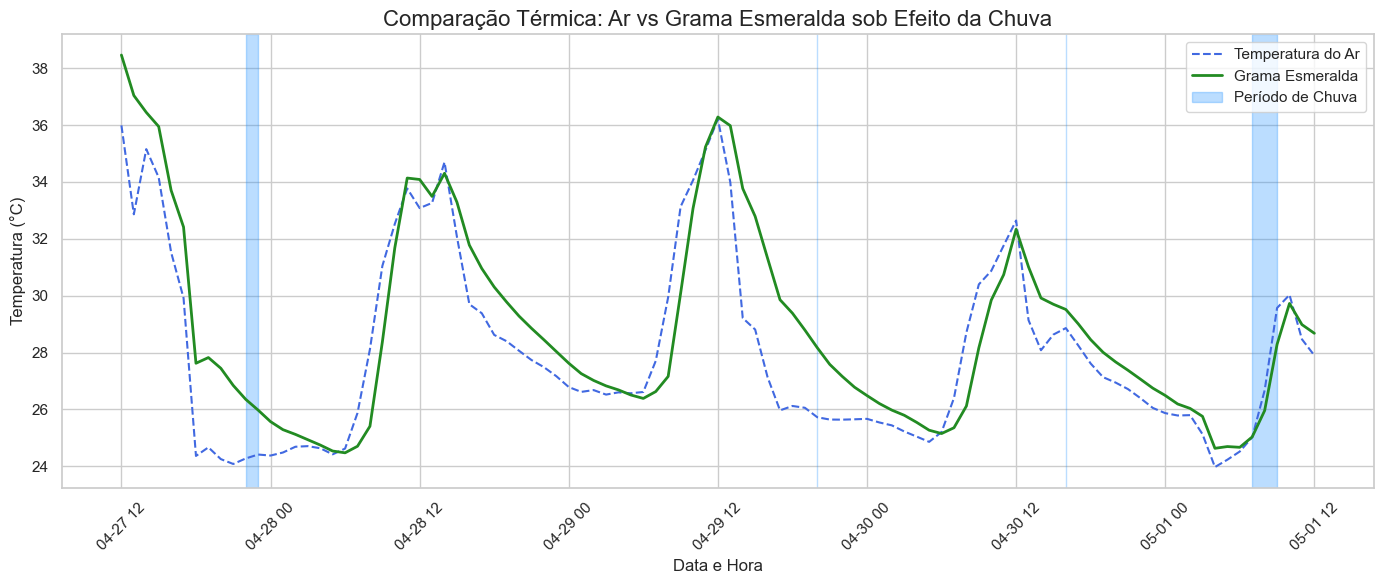

In [15]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# 2. Desenhando as duas linhas de temperatura
sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_ar', 
             label='Temperatura do Ar', color='royalblue', linestyle='--', ax=ax)

sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_esmeralda', 
             label='Grama Esmeralda', color='forestgreen', linewidth=2, ax=ax)

# 3. A MÁGICA DO SOMBREAMENTO DA CHUVA
# Pinta o fundo de cima a baixo onde a coluna 'chuva_mm_sum' for maior que zero
ax.fill_between(
    df_horario_final.index, 
    0, 1, 
    where=(df_horario_final['chuva_mm_sum'] > 0), 
    transform=ax.get_xaxis_transform(), 
    color='dodgerblue', 
    alpha=0.3, 
    label='Período de Chuva'
)

# 4. Ajustes visuais (Títulos e Eixos)
ax.set_title('Comparação Térmica: Ar vs Grama Esmeralda sob Efeito da Chuva', fontsize=16)
ax.set_xlabel('Data e Hora', fontsize=12)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
plt.xticks(rotation=45)

# 5. Organizando a legenda e exibindo
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

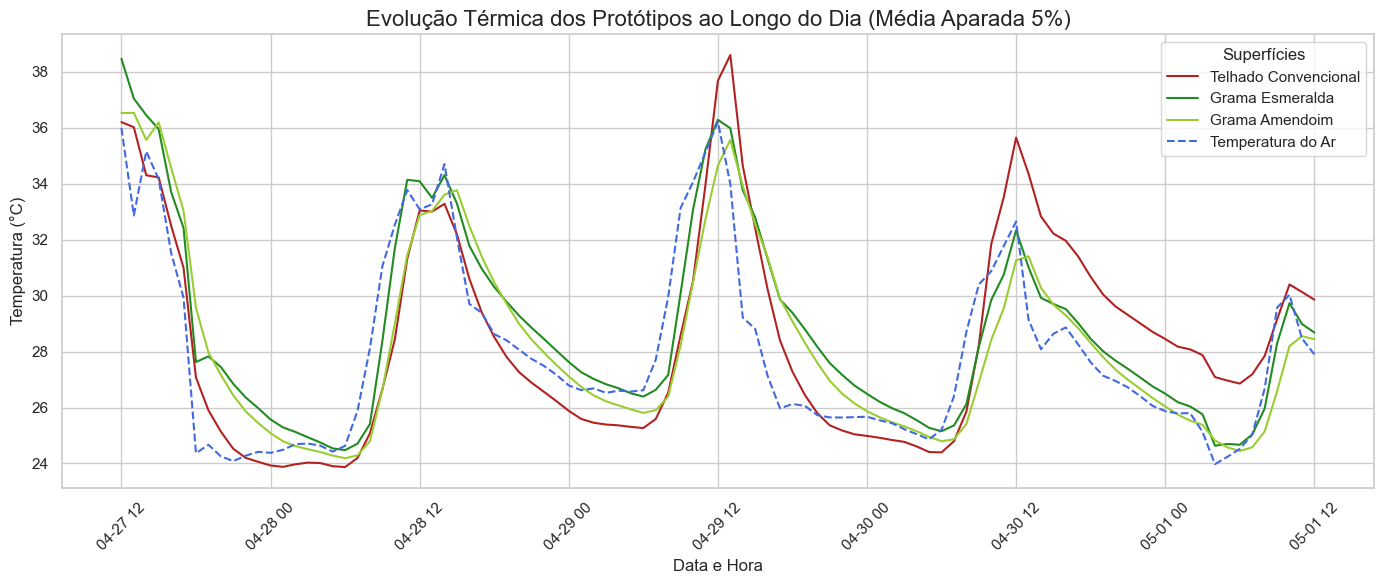

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Traçando as linhas de temperatura da superfície e do ar
sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_convencional', label='Telhado Convencional', color='firebrick')
sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_esmeralda', label='Grama Esmeralda', color='forestgreen')
sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_amendoim', label='Grama Amendoim', color='yellowgreen')
sns.lineplot(data=df_horario_final, x=df_horario_final.index, y='temp_ar', label='Temperatura do Ar', color='royalblue', linestyle='--')

# Organizando os títulos e rótulos
plt.title('Evolução Térmica dos Protótipos ao Longo do Dia (Média Aparada 5%)', fontsize=16)
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Superfícies')
plt.tight_layout()

# Exibindo o gráfico
plt.show()